# Домашнее задание "Тематическое моделирование"

## Импорт необходимых библиотек:

In [2]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 61.4 MB/s eta 0:00:00:00:010:01


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import io
import string
import json
import bz2
import pandas as pd
from collections import Counter
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from pymorphy3 import MorphAnalyzer

# import regex

# from scipy import sparse


# import numpy as np

# import seaborn as sns

# %pylab inline

In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Выгрузка данных из архива

In [ ]:
path_colab = '../content/drive/MyDrive/DeepLearning/banki_responses.json.bz2'
path = 'banki_responses.json.bz2'

In [10]:
responses = []
with bz2.BZ2File(path_colab, 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [02:29, 1340.45it/s]


Пример отзыва:

In [11]:
responses[-2:]

[{'city': None,
  'rating_not_checked': False,
  'title': 'В Альфа-Банк больше обращаться не буду.',
  'num_comments': 0,
  'bank_license': 'лицензия № 1326',
  'author': 'Ирина',
  'bank_name': 'Альфа-Банк',
  'datetime': '2005-04-14 15:16:00',
  'text': 'Пробовала 10.04.05 оформить товар в кредит в Альфа-Банке (компьютерный центр "Буденовский"), сказали что все оформление займет 20 минут, в результате прождала 2,5 (!!!!) часа. После чего сказали - приходите завтра. Люди, которые ждали оформления, были также недовольны. На следующий день в кредите отказали, хотя на мой взгляд причин никаких не было, постоянная московская прописка, стабильная зарплата, 2 выплаченных в срок кредита в других банках, да и сумма товара была небольшая.  В общем, на следующий день в том же компьютерном центре я оформила кредит в "HOME CREDIT", оформлен он был за 10 (!!!) минут. А в Альфа-Банк больше обращаться не буду. Остались самые негативные воспоминания.',
  'rating_grade': 1},
 {'city': None,
  'rating_

In [12]:
df = pd.DataFrame(responses)
df.head()

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,г. Ставрополь,False,Меняют проценты комиссии не предупредив и не ...,2,лицензия № 1481,643609,Сбербанк России,2015-06-05 13:51:01,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,г. Челябинск,False,Верните денежные средства за страховку,1,лицензия № 2766,anfisa-2003,ОТП Банк,2015-06-05 10:58:12,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


In [13]:
df_text = df[['text', 'rating_grade']].copy()
df_text.head(5)

,text,rating_grade
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


## Часть 1. Анализ текстов

### 1.1 Посчитать количество отзывов в разных городах и на разные банки

In [14]:
# Количество отзывов в разных городах
num_reviews_by_city = df['city'].value_counts()
num_reviews_by_city

,count
city,
г. Москва,55354
г. Санкт-Петербург,14342
г. Екатеринбург,2337
г. Новосибирск,2300
г. Нижний Новгород,1976
...,...
г. порхов,1
г. город Алматы,1
"г. Казань, Татарстан",1


In [15]:
# Количество отзывов на разные банки
num_reviews_by_bank = df['bank_name'].value_counts()
num_reviews_by_bank

,count
bank_name,
Сбербанк России,26327
Альфа-Банк,10224
ВТБ 24,8185
Русский Стандарт,7943
Хоум Кредит Банк,7549
...,...
Фемили,1
Современные Стандарты Бизнеса,1
Нэклис-Банк,1


### 1.2 Построить гистограммы длин отзывов в символах и в словах

Токенизация каждого отзыва с удалением знаков препинания

In [16]:
punctuation = string.punctuation + "``''...«»"
punctuation


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~``\'\'...«»'

In [17]:
# Функция для токенизации с удалением пунктуации
def tokenize_without_punctuation(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [token for token in tokens if token not in punctuation]
    return tokens

In [18]:
# Добавляем в датафрейм столбец с токенизированными отзывами
df_text['tokens'] = df_text['text'].apply(tokenize_without_punctuation)

In [19]:
df_text.head(5)

,text,rating_grade,tokens
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк..."


Токенизация каждого отзыва с удалением стоп-слов

In [20]:
# Загружаем стоп-слова
russian_stopwords = set(stopwords.words('russian'))
# Добавляем дополнительные стоп-слова
custom_stopwords = {'это', 'весь', 'мочь', 'также', 'очень', 'который', 'ещё', 'прошлый'}
russian_stopwords.update(custom_stopwords)

In [21]:
def tokenize_without_stop_words(text):
    tokens = [token for token in text if token not in russian_stopwords]
    return tokens


In [22]:
df_text['tokens_without_stop_words'] = df_text['tokens'].apply(tokenize_without_stop_words)
df_text.head(5)

,text,rating_grade,tokens,tokens_without_stop_words
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ..."


Токенизация каждого отзыва по леммам

In [23]:
pymorphy3_analyzer = MorphAnalyzer()

def tokenize_lemm(text):
    tokens = [pymorphy3_analyzer.parse(token)[0].normal_form for token in text if token not in russian_stopwords]
    return tokens


In [24]:
df_text['tokens_lemm'] = df_text['tokens'].apply(tokenize_lemm)
df_text.head(5)

,text,rating_grade,tokens,tokens_without_stop_words,tokens_lemm
0,Добрый день! Я не являюсь клиентом банка и пор...,NaN,"[добрый, день, я, не, являюсь, клиентом, банка...","[добрый, день, являюсь, клиентом, банка, поруч...","[добрый, день, являться, клиент, банк, поручит..."
1,Доброго дня! Являюсь держателем зарплатной кар...,NaN,"[доброго, дня, являюсь, держателем, зарплатной...","[доброго, дня, являюсь, держателем, зарплатной...","[добрый, день, являться, держатель, зарплатный..."
2,Здравствуйте! Дублирую свое заявление от 03.0...,NaN,"[здравствуйте, дублирую, свое, заявление, от, ...","[здравствуйте, дублирую, свое, заявление, 03.0...","[здравствуйте, дублировать, свой, заявление, 0..."
3,Добрый день!! Я открыл расчетный счет в СберБа...,NaN,"[добрый, день, я, открыл, расчетный, счет, в, ...","[добрый, день, открыл, расчетный, счет, сберба...","[добрый, день, открыть, расчётный, счёт, сберб..."
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN,"[04.03.2015, г., взяла, кредит, в, вашем, банк...","[04.03.2015, г., взяла, кредит, вашем, банке, ...","[04.03.2015, г., взять, кредит, ваш, банк, зая..."


In [25]:
df_text.to_csv('../content/drive/MyDrive/DeepLearning/banki_responses.csv', index=False)

In [26]:
pymorphy3_analyzer = MorphAnalyzer()

def tokenize_lemm_02(text):
    tokens = [pymorphy3_analyzer.parse(token)[0].normal_form for token in text if pymorphy3_analyzer.parse(token)[0].normal_form not in russian_stopwords]
    return tokens


Подсчет количества символов и слов в каждом отзыве

In [ ]:
df_text['tokens_lemm_02'] = df_text['tokens'].apply(tokenize_lemm_02)
df_text.head(5)

In [ ]:
df_text.to_csv('../content/drive/MyDrive/DeepLearning/banki_responses_02.csv', index=False)

In [19]:
# количество символов
df['char_count'] = df['text'].str.len()
# количество слов после токенизации
df['word_count'] = df['tokens'].str.len()
df[['char_count', 'word_count']].head()

,char_count,word_count
0,1523,220
1,1026,136
2,588,89
3,740,123
4,1896,305


Построение гистограмм

Text(0.5, 1.0, 'Распределение длины отзывов в словах')

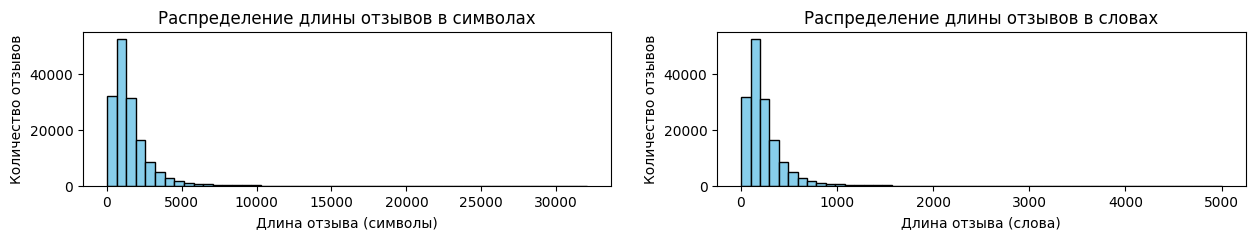

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 2))
axes[0].hist(df['char_count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Длина отзыва (символы)')
axes[0].set_ylabel('Количество отзывов')
axes[0].set_title('Распределение длины отзывов в символах')

axes[1].hist(df['word_count'], bins=51, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Длина отзыва (слова)')
axes[1].set_ylabel('Количество отзывов')
axes[1].set_title('Распределение длины отзывов в словах')


### 1.3 Найти 10 самых частых:
- слов
- слов без стоп-слов
- лемм
- существительных

In [21]:
# Формируем корпус
corpus = [token for tokens in df.tokens for token in tokens if token not in punctuation]
print(len(corpus))

36094083


Топ 10 слов

In [22]:
freq_dict = Counter(corpus)
top10 = [word for word in freq_dict.most_common(20)]
top10

[('в', 1322516),
 ('и', 1054485),
 ('не', 851742),
 ('на', 704396),
 ('что', 621783),
 ('я', 573896),
 ('с', 454545),
 ('по', 365188),
 ('мне', 320695),
 ('банка', 263957),
 ('а', 223339),
 ('но', 200005),
 ('банк', 196303),
 ('как', 195235),
 ('меня', 187152),
 ('это', 183054),
 ('у', 177323),
 ('за', 176669),
 ('все', 162365),
 ('о', 154864)]

Топ 10 слов без стоп-слов

In [24]:
# Корпус без стоп-слов
corpus_without_stopwords = [token for token in corpus if token not in russian_stopwords]
print(len(corpus_without_stopwords))

23017473


In [25]:
freq_dict = Counter(corpus_without_stopwords)
top10 = [word for word in freq_dict.most_common(20)]
top10

[('банка', 263957),
 ('банк', 196303),
 ('деньги', 130062),
 ('карту', 104947),
 ('карты', 100877),
 ('кредит', 80282),
 ('день', 75996),
 ('заявление', 69524),
 ('отделение', 66468),
 ('время', 65554),
 ('банке', 65400),
 ('счет', 55926),
 ('дней', 55625),
 ('года', 55398),
 ('рублей', 50437),
 ('карта', 49998),
 ('вопрос', 49316),
 ('ответ', 48306),
 ('сумму', 46746),
 ('2', 46312)]

Топ 10 лемм

In [26]:
pymorphy3_analyzer = MorphAnalyzer()

In [27]:
parsed = [pymorphy3_analyzer.parse(token)[0].normal_form for token in corpus_without_stopwords]
parsed[0]

'добрый'

In [35]:
len(parsed)

23017473

In [34]:
freq_lemm_dict = Counter(parsed)
top10 = [lemm for lemm in freq_lemm_dict.most_common(20)]
top10

[('банк', 624272),
 ('карта', 331815),
 ('деньга', 178338),
 ('день', 172634),
 ('мой', 167035),
 ('кредит', 154865),
 ('отделение', 143616),
 ('счёт', 140509),
 ('сотрудник', 133662),
 ('клиент', 132908),
 ('который', 115125),
 ('сказать', 114264),
 ('сумма', 110914),
 ('год', 103261),
 ('заявление', 103043),
 ('свой', 102319),
 ('вопрос', 97067),
 ('время', 94104),
 ('мочь', 85817),
 ('получить', 83472)]

Топ 10 существительных

In [36]:
nones = [pymorphy3_analyzer.parse(token)[0].normal_form for token in corpus_without_stopwords if 'NOUN' in pymorphy3_analyzer.parse(token)[0].tag]

In [37]:
freq_lemm_dict = Counter(nones)
top10 = [lemm for lemm in freq_lemm_dict.most_common(20)]
top10

[('банк', 624272),
 ('карта', 331815),
 ('деньга', 178338),
 ('день', 172634),
 ('кредит', 154865),
 ('отделение', 143616),
 ('счёт', 140509),
 ('сотрудник', 133662),
 ('клиент', 132908),
 ('сумма', 110914),
 ('год', 103261),
 ('заявление', 103043),
 ('вопрос', 97067),
 ('время', 94104),
 ('ответ', 76761),
 ('платёж', 76595),
 ('вклад', 75869),
 ('телефон', 74852),
 ('офис', 73307),
 ('договор', 72557)]

### Построить кривые Ципфа и Хипса

[('сотрудник', 133662), ('клиент', 132908)]

[('мошенничество', 3228), ('доверие', 2098)]

### Ответить на следующие вопросы:
- какое слово встречается чаще, "сотрудник" или "клиент"
- сколько раз встречаются слова "мощенничество" и "доверие"

In [40]:
[lemm for lemm in freq_lemm_dict.most_common() if lemm[0] in ['сотрудник', 'клиент']]

[('сотрудник', 133662), ('клиент', 132908)]

In [41]:
[lemm for lemm in freq_lemm_dict.most_common() if lemm[0] in ['мошенничество', 'доверие']]

[('мошенничество', 3228), ('доверие', 2098)]

## Часть 2. Тематическое моделирование

### Постройте несколько тематических моделей коллекции документов с разным числом тем. Приведите примеры понятных (интерпретируемых) тем.

### Найдите темы, в которых упомянуты конкретные банки (Сбербанк, ВТБ, другой банк). Можете ли вы их прокомментировать / объяснить?
Эта часть задания может быть сделана с использованием gensim.

## Часть 3. Классификация текстов

Сформулируем для простоты задачу бинарной классификации: будем классифицировать на два класса, то есть, различать резко отрицательные отзывы (с оценкой 1) и положительные отзывы (с оценкой 5).

### Составьте обучающее и тестовое множество: выберите из всего набора данных N1 отзывов с оценкой 1 и N2 отзывов с оценкой 5 (значение N1 и N2 – на ваше усмотрение). Используйте sklearn.model_selection.train_test_split для разделения

### Используйте любой известный вам алгоритм классификации текстов для решения задачи и получите baseline.
Сравните разные варианты векторизации текста: использование только униграм, пар или троек слов или с использованием символьных $n$-грам.

### Сравните, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков:
- 1-ый вариант: $tf-idf$ преобразование (sklearn.feature_extraction.text.TfidfTransformer) и сингулярное разложение (оно же – латентый семантический анализ) (sklearn.decomposition.TruncatedSVD),
- 2-ой вариант: тематические модели LDA (sklearn.decomposition.LatentDirichletAllocation).
Используйте accuracy и F-measure для оценки качества классификации.

В ноутбуке, размещенном в папке репозитория. написан примерный Pipeline для классификации текстов.

Эта часть задания может быть сделана с использованием sklearn.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# !!! На каждом этапе Pipeline нужно указать свои параметры
# 1-ый вариант: tf-idf + LSI
# 2-ой вариант: LDA

# clf = Pipeline([
#     ('vect', CountVectorizer(analyzer = 'char', ngram_range={4,6})),
#     ('clf', RandomForestClassifier()),
# ])



clf = Pipeline([ 
    ('vect', CountVectorizer()), 
    ('tfidf', TfidfTransformer()), 
    ('tm', TruncatedSVD()), 
    ('clf', RandomForestClassifier())
])


NameError: name 'TfidfTransformer' is not defined